Для аналізу було взято датасет продажів кав'ярні за рік.

**Мета:** провести очищення та дослідницький аналіз даних (EDA), а саме дізнатися найпопулярніший товар, найприбутковіший товар, найпопулярнішу точку та найприбутковіший місяць.

## План роботи:

### Підготовка даних
- **Крок 1. Завантаження та первинний огляд даних**
- **Крок 2. Перетворення даних**
  - Приведення до єдиного вигляду (виправлення помилок у написанні, перетворення невідомих значень на `NaN`, зведення до потрібного типу даних)
- **Крок 3. Видалення повних дублікатів**
- **Крок 4. Робота з пропущеними значеннями**
  - Виявлення невідповідностей
  - Заміна значень та видалення неінформативних рядків
- **Крок 5. Обробка аномалій та викидів**
  - Виявлення викидів
  - Обробка викидів за потреби
- **Крок 6. Додавання нових стовпчиків для майбутніх розрахунків**

### Аналіз даних (EDA)
- **Крок 1. EDA**
  - Середній та медіанний чек
  - Середня кількість покупок за місяць
  - Середня кількість покупок за днями тижня
  - Прибуток за місяцями
  - Топ-5 товарів за прибутком та за продажами за рік
  - Продажі «з собою» проти продажів «у закладі»

# Підготовка даних

## 1. Завантаження та первинний огляд даних

In [117]:
import pandas as pd, numpy as np, scipy.stats as sp, matplotlib.pyplot as plt, seaborn as sb

In [118]:
df = pd.read_csv('./dirty_cafe_sales.csv')

In [119]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [120]:
df.shape

(10000, 8)

In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [122]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


Задля виявлення помилок у введенні необхідно дослідити унікальні значення для кожного стовпця датасету. Це дозволить уніфікувати текстові дані та провести стандартизацію перед подальшим очищенням.

In [123]:
for cols in df.columns:
    print(cols,df[cols].nunique())

Transaction ID 10000
Item 10
Quantity 7
Price Per Unit 8
Total Spent 19
Payment Method 5
Location 4
Transaction Date 367


In [124]:
for col in df.columns:
    print(col)
    print(df[col].unique(),"\n")

Transaction ID
<StringArray>
['TXN_1961373', 'TXN_4977031', 'TXN_4271903', 'TXN_7034554', 'TXN_3160411',
 'TXN_2602893', 'TXN_4433211', 'TXN_6699534', 'TXN_4717867', 'TXN_2064365',
 ...
 'TXN_1538510', 'TXN_3897619', 'TXN_2739140', 'TXN_4766549', 'TXN_7851634',
 'TXN_7672686', 'TXN_9659401', 'TXN_5255387', 'TXN_7695629', 'TXN_6170729']
Length: 10000, dtype: str 

Item
<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
Length: 11, dtype: str 

Quantity
<StringArray>
['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan]
Length: 8, dtype: str 

Price Per Unit
<StringArray>
['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN']
Length: 9, dtype: str 

Total Spent
<StringArray>
[    '4.0',    '12.0',   'ERROR',    '10.0',    '20.0',     '9.0',    '16.0',
    '15.0',    '25.0',     '8.0',     '5.0',     '3.0',     '6.0',       nan,
 'UNKNOWN',     '2.0',     '1.0',     '7.5',     '4.5',

## 2. Перетворення даних

Здійснено стандартизацію даних. Неідентифіковані запиcи до єдиного формату `NaN`, а також уніфіковано текстові та числові значення для забезпечення цілісності датасету перед подальшим аналізом.

In [125]:
df = df.replace(['ERROR','UNKNOWN'],np.nan)

Приведення типів даних до оптимальних (зміна текстових та числових форматів, приведення дат до `Datetime`)

In [126]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').astype('Int64')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce').astype('float64')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors ='coerce').astype('float64')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%Y-%m-%d', errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  str           
 1   Item              9031 non-null   str           
 2   Quantity          9521 non-null   Int64         
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    6822 non-null   str           
 6   Location          6039 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: Int64(1), datetime64[us](1), float64(2), str(4)
memory usage: 634.9 KB


In [127]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,NaN,3,3.0,9.0,NaN,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,NaN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


## 3. Видалення повних дублікатів

Проведено перевірку на наявність дублікатів унікальних ідентифікаторів (`transaction_id`)

In [128]:
df[df['Transaction ID'].duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


## 4. Робота з пропущеними значеннями

### Виявлення невідповідностей

Проведено первинну оцінку пропущених значень. Для цього побудовано теплову карту (Heatmap) для візуального аналізу розподілу пропусків та розраховано точний відсоток відсутніх даних у кожному стовпчику.

In [129]:
df.isnull().sum() / len(df) * 100

Transaction ID       0.00
Item                 9.69
Quantity             4.79
Price Per Unit       5.33
Total Spent          5.02
Payment Method      31.78
Location            39.61
Transaction Date     4.60
dtype: float64

<Axes: >

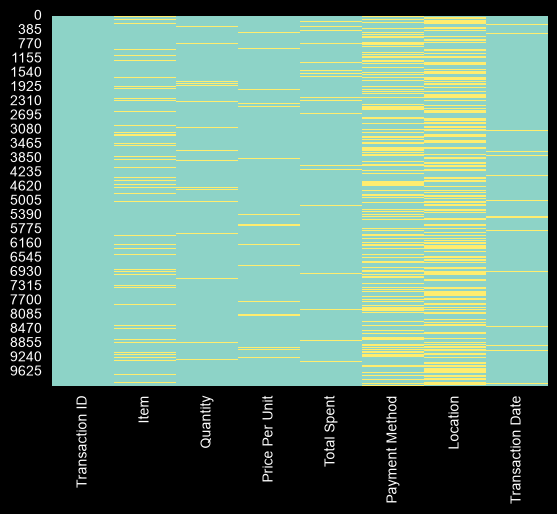

In [130]:
sb.heatmap(df.isnull(), cmap=sb.color_palette(), cbar=False)

Відновлення пропущених значень на основі наявних контекстних даних.

Проведено валідацію розрахункового поля Total Spent на основі Price Per Unit та Quantity: перевірено відповідність наявних значень

In [131]:
df[df['Total Spent'].isnull()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
25,TXN_7958992,Smoothie,3,4.0,NaN,NaN,NaN,2023-12-13
31,TXN_8927252,NaN,2,1.0,NaN,Credit Card,NaN,2023-11-06
42,TXN_6650263,Tea,2,1.5,NaN,NaN,Takeaway,2023-01-10
65,TXN_4987129,Sandwich,3,NaN,NaN,NaN,In-store,2023-10-20
...,...,...,...,...,...,...,...,...
9893,TXN_3809533,Juice,2,NaN,NaN,Digital Wallet,Takeaway,2023-02-02
9954,TXN_1191659,Coffee,4,2.0,NaN,Credit Card,In-store,2023-11-21
9977,TXN_5548914,Juice,2,3.0,NaN,Digital Wallet,In-store,2023-11-04
9988,TXN_9594133,Cake,5,3.0,NaN,NaN,NaN,NaT


In [132]:
df[df['Total Spent'].isnull() & (df['Price Per Unit'].notna() & df['Quantity'].notna())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
25,TXN_7958992,Smoothie,3,4.0,NaN,NaN,NaN,2023-12-13
31,TXN_8927252,NaN,2,1.0,NaN,Credit Card,NaN,2023-11-06
42,TXN_6650263,Tea,2,1.5,NaN,NaN,Takeaway,2023-01-10
94,TXN_6289610,Juice,3,3.0,NaN,Cash,Takeaway,2023-08-07
...,...,...,...,...,...,...,...,...
9890,TXN_2749289,Smoothie,2,4.0,NaN,Digital Wallet,Takeaway,2023-05-05
9954,TXN_1191659,Coffee,4,2.0,NaN,Credit Card,In-store,2023-11-21
9977,TXN_5548914,Juice,2,3.0,NaN,Digital Wallet,In-store,2023-11-04
9988,TXN_9594133,Cake,5,3.0,NaN,NaN,NaN,NaT


In [133]:
df.loc[df['Total Spent'].isnull() & (df['Price Per Unit'].notna() & df['Quantity'].notna()), ['Total Spent']] = df['Price Per Unit'] * df['Quantity']

df[df['Total Spent'].isnull() & (df['Price Per Unit'].notna() & df['Quantity'].notna())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


За аналогічним алгоритмом проведено зворотний розрахунок для полів Quantity та Price Per Unit

Quantity

In [134]:
df[df['Quantity'].isnull() & (df['Price Per Unit'].notna() & df['Total Spent'].notna())] # 'Quantity' nan, а 'Total Spent' і 'Price Per Unit' не nan

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
20,TXN_3522028,Smoothie,<NA>,4.0,20.0,Cash,In-store,2023-04-04
55,TXN_5522862,Cookie,<NA>,1.0,2.0,Credit Card,Takeaway,2023-03-19
57,TXN_2080895,Cake,<NA>,3.0,3.0,Digital Wallet,In-store,2023-04-19
66,TXN_8501819,Juice,<NA>,3.0,6.0,Cash,NaN,2023-03-30
117,TXN_2148617,Juice,<NA>,3.0,9.0,Digital Wallet,NaN,2023-01-10
...,...,...,...,...,...,...,...,...
9932,TXN_8502079,Tea,<NA>,1.5,3.0,Cash,NaN,2023-04-20
9935,TXN_9778251,Tea,<NA>,1.5,6.0,NaN,Takeaway,2023-11-09
9944,TXN_7495283,Cake,<NA>,3.0,15.0,Credit Card,Takeaway,2023-04-14
9957,TXN_6487003,Coffee,<NA>,2.0,8.0,Credit Card,Takeaway,2023-11-15


In [135]:
df.loc[df['Quantity'].isnull() & (df['Price Per Unit'].notna() & df['Total Spent'].notna()), 'Quantity'] = df['Total Spent'] / df['Price Per Unit']

Price Per Unit

In [136]:
df[df['Price Per Unit'].isnull() & (df['Quantity'].notna() & df['Total Spent'].notna())] # 'Price Per Unit' nan, а 'Total Spent' і 'Quantity' не nan

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
56,TXN_3578141,Cake,5,NaN,15.0,NaN,Takeaway,2023-06-27
68,TXN_8427104,Salad,2,NaN,10.0,NaN,In-store,2023-10-27
85,TXN_8035512,Tea,3,NaN,4.5,Cash,NaN,2023-10-29
104,TXN_7447872,Juice,2,NaN,6.0,NaN,NaN,NaT
118,TXN_4633784,NaN,5,NaN,15.0,NaN,In-store,2023-02-06
...,...,...,...,...,...,...,...,...
9924,TXN_5981429,Juice,2,NaN,6.0,Digital Wallet,NaN,2023-12-24
9926,TXN_2464706,Cake,4,NaN,12.0,Digital Wallet,Takeaway,2023-11-09
9961,TXN_2153100,Tea,2,NaN,3.0,Cash,NaN,2023-12-29
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02


In [137]:
df.loc[df['Price Per Unit'].isnull() & (df['Quantity'].notna() & df['Total Spent'].notna()), ['Price Per Unit']] = df['Total Spent'] / df['Quantity']

Здійснено спробу відновлення назв товарів на основі відомої ціни (Price Per Unit). Товари зі співпадаючими ціновими категоріями залишено невизначеними задля уникнення викривлення даних.

In [138]:
menu = df[df['Price Per Unit'].notna()].groupby('Item')['Price Per Unit'].unique().explode() # меню

dub_item_price = menu[menu.duplicated(keep=False)]
un_item_price = menu[~menu.duplicated(keep=False)]
#len(menu) == len(dub_item_price) + len(un_item_price)
price_to_index = pd.Series(data = un_item_price.index, index=un_item_price.values)


condition = [
    df['Item'].notna(),
    df['Price Per Unit'].isin(dub_item_price.values),
    df['Price Per Unit'].isin(un_item_price.values)
]

res = [
    df['Item'],
    'DUB_PRICE',
    df['Price Per Unit'].map(price_to_index)
]

df['Item'] = np.select(
    condition,
    res,
    default= 'ERROR'
)

На основі сформованого меню та ідентифікованих позицій відновлено всі відсутні числові показники (Total Spent, Price Per Unit, Quantity), що дозволило повністю ліквідувати пропуски в розрахункових полях.

In [139]:
menu = menu.astype('float64')

In [140]:
# len(df[~((df['Item'] == 'DUB_PRICE') & (df['Item'] == 'ERROR')) & df['Price Per Unit'].isnull()])

cond = ~((df['Item'] == 'DUB_PRICE') | (df['Item'] == 'ERROR')) & df['Price Per Unit'].isnull()
df.loc[cond, 'Price Per Unit'] = df.loc[cond, 'Item'].map(menu)

In [141]:
cond1 = ~((df['Item'] == 'DUB_PRICE') | (df['Item'] == 'ERROR')) & (df['Price Per Unit'].notna()) & (df['Quantity'].isnull()) & (df['Total Spent'].notna())

df.loc[cond1, 'Quantity'] = df['Total Spent'] / df['Price Per Unit']

In [142]:
df[df['Item'] == 'ERROR']

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1761,TXN_3611851,ERROR,4,NaN,NaN,Credit Card,NaN,2023-02-09
2289,TXN_7524977,ERROR,4,NaN,NaN,NaN,NaN,2023-12-09
3779,TXN_7376255,ERROR,<NA>,NaN,25.0,NaN,In-store,2023-05-27
4152,TXN_9646000,ERROR,2,NaN,NaN,NaN,In-store,2023-12-14
7597,TXN_1082717,ERROR,<NA>,NaN,9.0,Digital Wallet,In-store,2023-12-13
9819,TXN_1208561,ERROR,<NA>,NaN,20.0,Credit Card,NaN,2023-08-19


Усі доступні зауваження та непрямі зв'язки між полями вичерпано, пропуски, що підлягали відновленню, успішно заповнено. Переходимо до наступного етапу очищення та обробки даних.

In [143]:
df[(df['Quantity'].isnull()) & (df['Price Per Unit'].isnull()) & (df['Total Spent'].isnull())]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


### Заміна значень та видалення неінформативних рядків

Проміжний контроль

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  str           
 1   Item              10000 non-null  str           
 2   Quantity          9977 non-null   Int64         
 3   Price Per Unit    9994 non-null   float64       
 4   Total Spent       9960 non-null   float64       
 5   Payment Method    6822 non-null   str           
 6   Location          6039 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: Int64(1), datetime64[us](1), float64(2), str(4)
memory usage: 634.9 KB


In [145]:
df.isnull().sum() / len(df) * 100

Transaction ID       0.00
Item                 0.00
Quantity             0.23
Price Per Unit       0.06
Total Spent          0.40
Payment Method      31.78
Location            39.61
Transaction Date     4.60
dtype: float64

<Axes: >

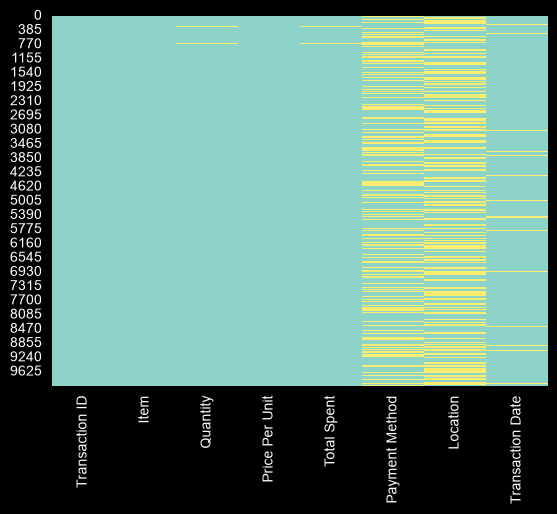

In [146]:
sb.heatmap(df.isnull(), cmap=sb.color_palette(), cbar=False)

In [147]:
df.loc[df['Item'].isnull(), 'Item'] = 'Unknow'

In [148]:
df.loc[df['Payment Method'].isnull(), 'Payment Method'] = 'Unknow'

In [149]:
df['Location'] = df['Location'].replace(np.nan, 'Unknow')

Проміжний контроль

In [150]:
df.isnull().sum() / len(df) * 100

Transaction ID      0.00
Item                0.00
Quantity            0.23
Price Per Unit      0.06
Total Spent         0.40
Payment Method      0.00
Location            0.00
Transaction Date    4.60
dtype: float64

<Axes: >

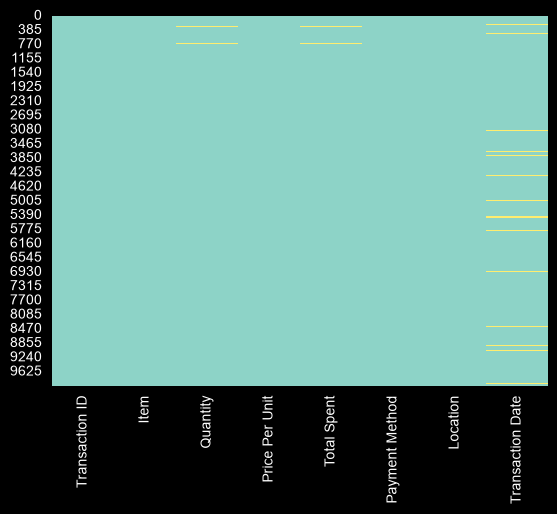

In [151]:
sb.heatmap(df.isnull(), cmap=sb.color_palette(), cbar=False)

## 5. Обробка аномалій та викидів

Для знаходження викидів та аномалій був використаний метод півтора міжквартильного інтервалу від першого та третього квантилю

In [152]:
k = 1.5
iqr_total = sp.iqr(df['Total Spent'])

cond0 = df['Total Spent'] > df['Total Spent'].quantile(0.75) + k * iqr_total
cond1 = df['Total Spent'] < df['Total Spent'].quantile(0.25) - k * iqr_total

df[cond0 | cond1]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


Аномалій не було виявлено.

## 6. Додавання нових стовпчиків для майбутніх розрахунків

Для майбутніх розрахунків нам потрібні тільки назви дня та місяця для кожного замовлення.

In [153]:
df['Day of week'] = df['Transaction Date'].dt.day_name()

In [154]:
df['Month'] = df['Transaction Date'].dt.to_period('M')

# Аналіз даних (EDA)

In [155]:
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day of week,Month
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,2023-09
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,Tuesday,2023-05
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,Wednesday,2023-07
3,TXN_7034554,Salad,2,5.0,10.0,Unknow,Unknow,2023-04-27,Thursday,2023-04
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday,2023-06
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,Unknow,2023-03-31,Friday,2023-03
6,TXN_4433211,DUB_PRICE,3,3.0,9.0,Unknow,Takeaway,2023-10-06,Friday,2023-10
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,Unknow,2023-10-28,Saturday,2023-10
8,TXN_4717867,DUB_PRICE,5,3.0,15.0,Unknow,Takeaway,2023-07-28,Friday,2023-07
9,TXN_2064365,Sandwich,5,4.0,20.0,Unknow,In-store,2023-12-31,Sunday,2023-12


In [156]:
avg_receipt = df['Total Spent'].mean()
median_receipt = df['Total Spent'].median()

In [157]:
avg_quantity = df['Quantity'].mean()
median_quantity = df['Quantity'].median()

In [158]:
df['Transaction Date'].isnull().sum()

np.int64(460)

In [159]:
monthly_profit = df.groupby('Month')['Total Spent'].sum()
day_of_week_sales = df.groupby('Day of week')['Quantity'].sum() / df['Quantity'].sum()

In [160]:
cond = df['Item'] != 'DUB_PRICE'
top_5_quantity_item = df[cond].groupby('Item')['Quantity'].mean().round(3).sort_values(ascending=False).iloc[0:5]
top_5_spent_item = df[cond].groupby('Item')['Total Spent'].mean().round(3).sort_values(ascending=False).iloc[0:5]

In [161]:
df['Location'] = df['Location'].replace(np.nan, 'Unknow')
loc_check = df.groupby('Location')['Transaction ID'].count() / df['Transaction ID'].count() * 100
loc_check

Location
In-store    30.17
Takeaway    30.22
Unknow      39.61
Name: Transaction ID, dtype: float64

In [162]:
print(f'Profits: {df['Total Spent'].sum()}\n')
print('___'*10)
print(f'AVG receipt: {avg_receipt.round(2)}\nMedian receipt: {median_receipt.round(2)}\n')
print('___'*10)
print(f'AVG quantity: {avg_quantity.round(2)}\nMedian quantity: {median_quantity.round(2)}\n')
print('___'*10)
print(f'Monthly profit: {monthly_profit.round(3)}\n\nDay of week profit (%): {day_of_week_sales}\n')
print('___'*10)
print(f'Top 5 products by quantity:{top_5_quantity_item}\n\nTop 5 products by quantity:{top_5_spent_item}\n')
print('___'*10)
print(f'In-store vs Takeaway: {loc_check}')

Profits: 88952.0

______________________________
AVG receipt: 8.93
Median receipt: 8.0

______________________________
AVG quantity: 3.02
Median quantity: 3.0

______________________________
Monthly profit: Month
2023-01    7242.0
2023-02    6633.5
2023-03    7214.5
2023-04    7168.0
2023-05    6941.5
2023-06    7350.0
2023-07    6877.5
2023-08    7077.5
2023-09    6846.0
2023-10    7302.0
2023-11    6957.0
2023-12    7177.0
Freq: M, Name: Total Spent, dtype: float64

Day of week profit (%): Day of week
Friday       0.139165
Monday       0.136746
Saturday     0.134592
Sunday       0.137707
Thursday     0.138801
Tuesday      0.134791
Wednesday    0.130948
Name: Quantity, dtype: Float64

______________________________
Top 5 products by quantity:Item
ERROR       3.333
Smoothie    3.049
Cake        3.047
Sandwich    3.043
Coffee      3.036
Name: Quantity, dtype: Float64

Top 5 products by quantity:Item
ERROR       18.000
Salad       15.028
Smoothie    12.209
Sandwich    12.167
Cake        

Запис фінальної таблиці у файл csv

In [163]:
df.fillna(0).to_csv('clean_data.csv', index=False)